# What's next after ARI clustering probe?


ARI have been run to find the best leiden resolution for the data, now we must transfer this obs and obsm columns to our orginial adata and reorganize cluster labels by % of prediction ('top3_labels_per_cluster.csv').

In [1]:
import scanpy as sc, json
import pandas as pd 
import numpy as np 

In [4]:


OUT = "/home/mdiaz/HCC_project/hcc_adata"
ad  = sc.read_h5ad(f"{OUT}/adata_with_scvi_best.h5ad")

# 1) Leer mejor configuración y confirmar n_clusters
best = json.load(open(f"{OUT}/best_config.json"))
print(best)
print("n_clusters:", ad.obs["leiden_best"].nunique())

{'metric': 'cosine', 'k': 10, 'resolution': 0.2, 'ARI': 0.48376104023915745, 'silhouette_euclid_on_scVI': 0.1375591903924942, 'n_clusters': 18, 'key': 'leiden_cosine_10_0.2'}
n_clusters: 18


In [6]:
# 2) UMAP en X_scVI y guardar PNG
if "X_umap" not in ad.obsm:
    sc.pp.neighbors(ad, use_rep="X_scVI", n_neighbors=int(best["k"]), metric=best["metric"])
    sc.tl.umap(ad, min_dist=0.4, spread=1.0)
sc.pl.umap(ad, color=["leiden_best", "predicted"], wspace=0.4, save="_best_vs_pred.png", show=False)

[<Axes: title={'center': 'leiden_best'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'predicted'}, xlabel='UMAP1', ylabel='UMAP2'>]

In [7]:
# 3) Top etiquetas por cluster (para diagnóstico rápido)
ct = pd.crosstab(ad.obs["leiden_best"], ad.obs["predicted"])
top = (ct.div(ct.sum(1), axis=0).stack()
         .groupby(level=0).nlargest(3).to_frame("prop"))
top.to_csv(f"{OUT}/top3_labels_per_cluster.csv")

/tmp/ipykernel_1758909/3288520017.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top = (ct.div(ct.sum(1), axis=0).stack()


In [8]:
# Paths (edit)
SRC = "/home/mdiaz/HCC_project/hcc_adata/adata_with_scvi_best.h5ad"   
DST = "/home/mdiaz/HCC_project/hcc_adata/1_5T_unintegrated_CellTypeFromPred.h5ad"  
OUT = "/home/mdiaz/HCC_project/hcc_adata/1_5T_unintegrated_bestClustering.h5ad"

# Load
ad_src = sc.read_h5ad(SRC)   # has 'leiden_best' and X_scVI
ad_dst = sc.read_h5ad(DST)   # your working AnnData

# 1) Align by cell barcodes
# Keep target order; select only cells present in both
common = ad_dst.obs_names[ad_dst.obs_names.isin(ad_src.obs_names)]
if common.size == 0:
    raise ValueError("No overlapping cells between source and destination AnnData.")

coverage = common.size / ad_dst.n_obs
print(f"Coverage on destination: {coverage:.1%} ({common.size}/{ad_dst.n_obs})")


Coverage on destination: 100.0% (40771/40771)


In [9]:
# 2) Transfer obs columns
cols_to_copy = ["leiden_best"]  # add more if you need specific partitions
for col in cols_to_copy:
    if col not in ad_src.obs.columns:
        print(f"Warning: '{col}' not in source; skipping.")
        continue
    ad_dst.obs.loc[common, col] = ad_src.obs.loc[common, col].astype("category")


In [10]:
# 3) Transfer colors in .uns (optional but useful for plotting)
for key in ["leiden_best_colors", "predicted_colors"]:
    if key in ad_src.uns:
        ad_dst.uns[key] = ad_src.uns[key]

# 4) Transfer scVI latent to .obsm (recommended)
if "X_scVI" in ad_src.obsm:
    n_lat = ad_src.obsm["X_scVI"].shape[1]
    # Prepare a full matrix (NaNs for cells not in 'common')
    X = np.full((ad_dst.n_obs, n_lat), np.nan, dtype=np.float32)
    # Build indexers for fast aligned assignment
    src_pos = pd.Index(ad_src.obs_names).get_indexer(common)
    dst_pos = pd.Index(ad_dst.obs_names).get_indexer(common)
    X[dst_pos, :] = ad_src.obsm["X_scVI"][src_pos, :]
    ad_dst.obsm["X_scVI"] = X
else:
    print("Warning: 'X_scVI' missing in source; skipping latent transfer.")


In [11]:
# 5) (Optional) Recompute neighbors/UMAP on destination using the transferred X_scVI
#    Only if you want UMAP consistent with the best k/metric you chose.
sc.pp.neighbors(ad_dst, use_rep="X_scVI", n_neighbors=10, metric="cosine")
sc.tl.umap(ad_dst)

# 6) Save a new file to avoid overwriting your base object
ad_dst.write(OUT, compression="gzip")
print("Saved:", OUT)

2025-10-09 16:46:25.930454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-09 16:46:25.948137: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-09 16:46:25.953332: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 16:46:25.967290: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 16:46:27.018082: W tensorflow/comp

Saved: /home/mdiaz/HCC_project/hcc_adata/1_5T_unintegrated_bestClustering.h5ad


# Relabeling 

In [12]:
adata = sc.read_h5ad('/home/mdiaz/HCC_project/hcc_adata/1_5T_unintegrated_bestClustering.h5ad')

In [13]:
corrected_cell_labels={"0":"TAM",
"1":"T cells",
"2":"TEC",
"3":"Malignant",
"4":"Neutrophil",
"5":"TAM",
"6":"NK-TR-CD160",
"7":"Malignant",
"8":"B cells",
"9":"cDCs",
"10":"B cells",
"11":"Neutrophil",
"12":"CAF",
"13":"Hep",
"14":"B cells",
"15":"Basophil",
"16":"TEC",
"17":"Macrophage",
}

In [13]:
adata.obs['Cell_Type'] = adata.obs.leiden_best.map(corrected_cell_labels)
sc.pl.umap(adata, color=['Cell_Type'], s=2, legend_loc='on data')

SyntaxError: invalid syntax (174917444.py, line 1)

# Verification WITH scANVI labeling

In [15]:
df = adata.obs[['CellType', 'transfer_score', 'leiden_best']].copy()

# Etiqueta mayoritaria por cluster (si hay empate, toma la primera moda)
labels = df.groupby('leiden_best')['CellType'].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]
)

# Promedio de transfer_score por cluster
scores = df.groupby('leiden_best')['transfer_score'].mean()

# Tabla final
mapping_res = pd.concat(
    [labels.rename('majority_celltype'),
     scores.rename('mean_transfer_score')],
    axis=1
).reset_index()

mapping_res.head(50)

/tmp/ipykernel_3984749/127687806.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = df.groupby('leiden_best')['CellType'].agg(
/tmp/ipykernel_3984749/127687806.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores = df.groupby('leiden_best')['transfer_score'].mean()


,leiden_best,majority_celltype,mean_transfer_score
0,0,TAM,0.895413
1,1,T cells,0.864879
2,2,TEC,0.908876
3,3,tumor,0.919494
4,4,neutrophil,0.903003
5,5,TAMs,0.877203
6,6,NK-CD160-tissue resident,0.931027
7,7,Malignant cells,0.854687
8,8,B cells,0.965454
9,9,conventional dendritic cell,0.916931


In [18]:
adata.write_h5ad('/home/mdiaz/HCC_project/hcc_adata/2T_unintegrated_bestClustering.h5ad')

# Re clustering (pocos cluster y tipos celulares ocn ARI)

In [2]:
adata = sc.read_h5ad("/home/mdiaz/HCC_project/hcc_adata/1_5T_unintegrated_CellTypeFromPred.h5ad")
adata

AnnData object with n_obs × n_vars = 40771 × 23018
    obs: 'Patient', 'DX', 'Sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'doublet', 'CellType', 'Batch', 'predicted', 'transfer_score'
    var: 'n_cells'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [3]:
adata.obs.predicted.unique()

['T cells', 'TAMs', 'B cells', 'Malignant cells', 'c3-TPSB2-Mast cells', ..., 'c0-LUM-inflammatory CAF', 'fibroblast', 'c4-RGS5-endothelial', 'c2-APOA1-hepatocyte like CAF', 'unspecified']
Length: 49
Categories (49, object): ['B cells', 'CAFs', 'CD4-CD69-memory T cells', 'CD4-FOXP3-regulatory T cells', ..., 'plasmacytoid dendritic cell', 'tumor', 'unclassified', 'unspecified']

2025-10-14 12:40:17.010522: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 12:40:17.222843: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 12:40:17.336362: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 12:40:18.087010: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-14 12:40:26.552253: W tensorflow/comp

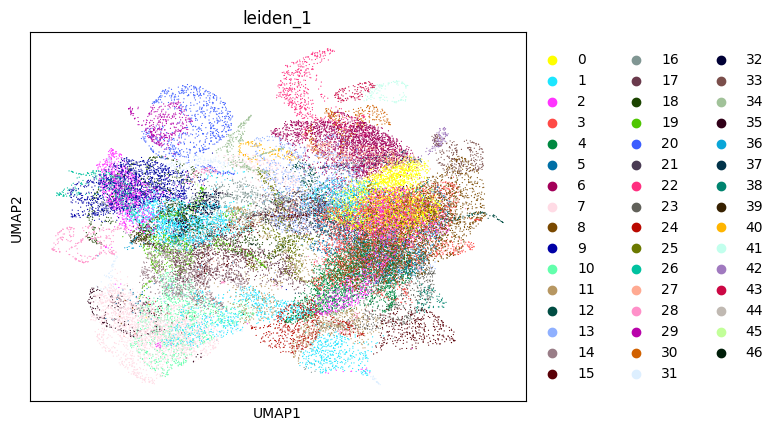

In [4]:
import scanpy as sc

# asumiendo que tu objeto es `adata`

# 1) Grafo de vecinos (usa la representación PCA ya calculada)
sc.pp.neighbors(
    adata,
    n_neighbors=10,      # ajusta según tu dataset
    n_pcs=50,            # usa los PCs que te funcionen mejor
    use_rep='X_pca'      # usa la matriz PCA existente
)

# 2) Clustering Leiden a resolución 0.8
sc.tl.leiden(
    adata,
    resolution=1.0,
    key_added='leiden_1',
    random_state=0
)

# (opcional) Visualiza en UMAP coloreando por el cluster Leiden
sc.pl.umap(adata, color='leiden_1')


In [23]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# Si ya tienes columnas de scANVI:
# - adata.obs['predicted'] : etiqueta argmax
# - adata.obs['transfer_score'] : prob. máxima (confianza)
# si no, obtén probs con scanvi_model.predict(adata, soft=True)

# Acepta predicción cuando la confianza sea alta
thr = 0.8
pred = adata.obs['predicted']

# Asegura tipo categórico y agrega la categoría faltante
if not pd.api.types.is_categorical_dtype(pred):
    pred = pred.astype('category')
pred = pred.cat.add_categories(['Unknown_lowconf'])

# Si transfer_score no es numérico, conviértelo
ts = pd.to_numeric(adata.obs['transfer_score'], errors='coerce')

adata.obs['label_cell'] = pred.where(ts >= thr, other='Unknown_lowconf')
# Suavizado por kNN para las de baja confianza
X = adata.obsp.get('connectivities', None)
if X is None:
    nbrs = NearestNeighbors(n_neighbors=10, metric='cosine').fit(adata.obsm['X_scVI'])
    indices = nbrs.kneighbors(return_distance=False)
else:
    # usa los 15 más conectados en el grafo
    indices = np.argsort(-X.toarray(), axis=1)[:, :15]

labels = adata.obs['label_cell'].values.astype(object)
pred = adata.obs['predicted'].values
conf = adata.obs['transfer_score'].values

for i in np.where(labels == "Unknown_lowconf")[0]:
    neigh = indices[i]
    # voto mayoritario ponderado por confianza
    lbls = pred[neigh]
    wgts = conf[neigh]
    dfw = pd.DataFrame({'l': lbls, 'w': wgts}).groupby('l')['w'].sum().sort_values(ascending=False)
    labels[i] = dfw.index[0]

adata.obs['label_cell_smoothed'] = labels


/tmp/ipykernel_1758909/3561603065.py:15: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(pred):
/tmp/ipykernel_1758909/3561603065.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfw = pd.DataFrame({'l': lbls, 'w': wgts}).groupby('l')['w'].sum().sort_values(ascending=False)


In [28]:
import pandas as pd
import numpy as np

# Elige la columna de etiqueta final
label_col = 'label_cell_smoothed'   # o 'label_cell' si no hiciste el suavizado

# Subtabla
df = adata.obs[['leiden_1', label_col, 'transfer_score']].copy()

# Mayoría por clúster (si hay empate, toma la primera moda)
labels = df.groupby('leiden_1')[label_col].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]
)

# Pureza del clúster (proporción de la etiqueta dominante)
purity = df.groupby('leiden_1')[label_col].apply(
    lambda s: s.value_counts(normalize=True).iloc[0]
)

# Promedio de transfer_score por clúster
scores = df.groupby('leiden_1')['transfer_score'].mean()

# Tamaño del clúster
sizes = df.groupby('leiden_1').size()

# Tabla final (ordenada por el id del clúster)
mapping_res = (
    pd.concat([
        labels.rename('majority_celltype'),
        purity.rename('purity'),
        scores.rename('mean_transfer_score'),
        sizes.rename('n_cells')
    ], axis=1)
    .reset_index()
    .sort_values('leiden_1')
)

# (opcional) nombre “final” del clúster según pureza
mapping_res['cluster_name'] = np.where(
    mapping_res['purity'] >= 0.8,
    mapping_res['majority_celltype'],
    'Mixed'
)

# Vista rápida (como antes)
mapping_res.head(50)


/tmp/ipykernel_1758909/115173363.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = df.groupby('leiden_1')[label_col].agg(
/tmp/ipykernel_1758909/115173363.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purity = df.groupby('leiden_1')[label_col].apply(
/tmp/ipykernel_1758909/115173363.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scores = df.groupby('leiden_1')['transfer_score'].mean()
/tmp/ipyker

,leiden_1,majority_celltype,purity,mean_transfer_score,n_cells,cluster_name
0,0,TEC,0.283664,0.845474,3275,Mixed
1,1,tumor,0.461400,0.912474,2785,Mixed
2,2,tumor,0.571429,0.923448,2618,Mixed
3,3,T cells,0.338121,0.909730,2576,Mixed
4,4,TAM,0.797649,0.894870,2382,Mixed
5,5,CD8-CD69-memory T cells,0.208721,0.881360,2362,Mixed
6,6,TEC,0.896786,0.929578,2209,TEC
7,7,TAM,0.680657,0.904535,2192,Mixed
8,8,tumor,0.538986,0.881769,2052,Mixed
9,9,NK-CD160-tissue resident,0.515602,0.896475,1346,Mixed


In [29]:
adata.obs.label_cell_smoothed.unique()

['NK-CD160-tissue resident', 'TAMs', 'B cells', 'TAM', 'Malignant cells', ..., 'fibroblast', 'c2-APOA1-hepatocyte like CAF', 'c1-CXCL10-M1 Macrophage', 'unspecified', 'c4-RGS5-endothelial']
Length: 49
Categories (49, object): ['B cells', 'CAFs', 'CD4-CD69-memory T cells', 'CD4-FOXP3-regulatory T cells', ..., 'plasmacytoid dendritic cell', 'tumor', 'unclassified', 'unspecified']